# HyperVeg: Complete Pipeline

This notebook runs the full end-to-end hyperspectral vegetation analysis pipeline.

## Pipeline Overview:
1. Data Loading
2. Simulate Digital Numbers
3. Radiometric Calibration (DN -> Radiance)
4. Atmospheric Correction (Radiance -> Reflectance)
5. Spectral Indices
6. Jaya Band Selection (Patro et al. 2019)
7. Spectral Unmixing
8. SVM Classification
9. Visualizations

In [1]:
# Setup and Imports
import sys
import os
sys.path.append('..')

%matplotlib inline

import time
import logging
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

# Import modules
from src.data.loader import download_indian_pines, load_indian_pines, get_class_names, get_dataset_info
from src.pipeline.calibration import generate_synthetic_dn, apply_radiometric_calibration, validate_calibration
from src.pipeline.atmospheric import apply_atmospheric_correction
from src.pipeline.preprocessing import (
    remove_water_vapor_bands, remove_noisy_bands, normalize_reflectance, extract_pixel_matrix
)
from src.analysis.indices import compute_all_indices
from src.analysis.band_selection import run_jaya_with_ranking, apply_band_selection, plot_band_selection_results
from src.analysis.unmixing import extract_endmembers_manual, unmix_cube, compute_reconstruction_error
from src.models.svm_classifier import create_spatial_blocks, train_svm_classifier, run_spatial_cv
from src.models.evaluation import compute_metrics, plot_confusion_matrix, plot_classification_map
from src.visualization.plots import (
    plot_false_color_composite, plot_spectral_signatures, plot_spectral_indices_maps,
    plot_abundance_maps
)

# Setup paths
data_dir = Path("data")
outputs_dir = Path("outputs")
outputs_dir.mkdir(exist_ok=True)

print("Setup complete! Matplotlib configured for inline plotting.")
print(f"Data directory: {data_dir.absolute()}")
print(f"Outputs directory: {outputs_dir.absolute()}")


Setup complete! Matplotlib configured for inline plotting.
Data directory: c:\Users\Charan\Desktop\matter intelligence\notebooks\data
Outputs directory: c:\Users\Charan\Desktop\matter intelligence\notebooks\outputs


## STAGE 1: Data Loading

In [2]:
# Download and load Indian Pines dataset
print("="*70)
print("STAGE 1: DATA LOADING")
print("="*70)

stage_start = time.time()

# Download data if needed
print("\n[1.1] Downloading Indian Pines dataset...")
download_indian_pines(str(data_dir))

# Load dataset
print("\n[1.2] Loading dataset...")
cube, labels, wavelengths = load_indian_pines(str(data_dir))
class_names = get_class_names()
get_dataset_info(cube, labels)

stage_time = time.time() - stage_start
print(f"\n[OK] Stage 1 completed in {stage_time:.2f} seconds")

# Display basic info
print(f"\nCube shape: {cube.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Wavelengths shape: {wavelengths.shape}")
print(f"Wavelength range: {wavelengths.min():.1f} - {wavelengths.max():.1f} nm")

2026-02-25 09:51:25,643 - src.data.loader - INFO - Indian_pines_corrected.mat already exists, skipping download
2026-02-25 09:51:25,661 - src.data.loader - INFO - Indian_pines_gt.mat already exists, skipping download
2026-02-25 09:51:25,668 - src.data.loader - INFO - Loading hyperspectral cube...


STAGE 1: DATA LOADING

[1.1] Downloading Indian Pines dataset...

[1.2] Loading dataset...


2026-02-25 09:51:26,022 - src.data.loader - INFO - Loaded cube: shape (200, 145, 145), wavelength range 400.0-2500.0 nm



DATASET INFORMATION

Spatial Shape: 145 × 145 pixels
Number of Bands: 200
Wavelength Range: 400.0 - 2500.0 nm
Memory Usage: 16.04 MB (cube) + 0.08 MB (labels) = 16.12 MB total

Labeled Pixels: 10,249 / 21,025 (48.7%)

Class Distribution:
------------------------------------------------------------
Class ID   Class Name                          Count        Percentage
------------------------------------------------------------
0          Unlabeled                           10,776       51.25     %
1          Alfalfa                             46           0.22      %
2          Corn-notill                         1,428        6.79      %
3          Corn-mintill                        830          3.95      %
4          Corn                                237          1.13      %
5          Grass-pasture                       483          2.30      %
6          Grass-trees                         730          3.47      %
7          Grass-pasture-mowed                 28           0.13

## STAGE 2: Simulate Digital Numbers

In [3]:
# Generate synthetic DN from reflectance
print("\n" + "="*70)
print("STAGE 2: SIMULATE DIGITAL NUMBERS")
print("="*70)

stage_start = time.time()

print("\n[2.1] Generating synthetic DN from reflectance...")
dn_cube, gain_array, offset_array = generate_synthetic_dn(cube, wavelengths, seed=42)
print(f"  Generated DN cube: shape {dn_cube.shape}, range [{dn_cube.values.min()}, {dn_cube.values.max()}]")
print(f"  Gain range: [{gain_array.min():.6f}, {gain_array.max():.6f}]")
print(f"  Offset range: [{offset_array.min():.6f}, {offset_array.max():.6f}]")

stage_time = time.time() - stage_start
print(f"\n[OK] Stage 2 completed in {stage_time:.2f} seconds")


STAGE 2: SIMULATE DIGITAL NUMBERS

[2.1] Generating synthetic DN from reflectance...


2026-02-25 09:51:27,163 - src.pipeline.calibration - INFO - Generated synthetic DN cube: shape (200, 145, 145), range [65535, 65535]


  Generated DN cube: shape (200, 145, 145), range [65535, 65535]
  Gain range: [0.005055, 0.014869]
  Offset range: [-0.989877, 0.981010]

[OK] Stage 2 completed in 1.03 seconds


## STAGE 3: Radiometric Calibration (DN -> Radiance)

In [4]:
# Apply radiometric calibration
print("\n" + "="*70)
print("STAGE 3: RADIOMETRIC CALIBRATION (DN -> Radiance)")
print("="*70)

stage_start = time.time()

print("\n[3.1] Applying radiometric calibration...")
radiance_cube = apply_radiometric_calibration(dn_cube, gain_array, offset_array)
print(f"  Radiance range: [{np.nanmin(radiance_cube.values):.2f}, {np.nanmax(radiance_cube.values):.2f}] W/m²/sr/μm")

print("\n[3.2] Validating calibration...")
validation_results = validate_calibration(cube, radiance_cube, gain_array, offset_array)
print(f"  Mean correlation: {validation_results['mean_correlation']:.4f}")
print(f"  Mean RMSE: {validation_results['mean_rmse']:.4f}")
print(f"  Validation passed: {validation_results['validation_passed']}")

stage_time = time.time() - stage_start
print(f"\n[OK] Stage 3 completed in {stage_time:.2f} seconds")


STAGE 3: RADIOMETRIC CALIBRATION (DN -> Radiance)

[3.1] Applying radiometric calibration...


2026-02-25 09:51:27,568 - src.pipeline.calibration - INFO - Applied radiometric calibration: radiance range [332.03, 974.02] W/m²/sr/μm


  Radiance range: [332.03, 974.02] W/m²/sr/μm

[3.2] Validating calibration...


2026-02-25 09:51:28,318 - src.pipeline.calibration - INFO - Calibration validation: mean correlation = 0.0000, mean RMSE = 2676.0425, passed = False


  Mean correlation: 0.0000
  Mean RMSE: 2676.0425
  Validation passed: False

[OK] Stage 3 completed in 1.12 seconds


## STAGE 4: Atmospheric Correction (Radiance -> Reflectance)

In [5]:
# Apply atmospheric correction
print("\n" + "="*70)
print("STAGE 4: ATMOSPHERIC CORRECTION (Radiance -> Reflectance)")
print("="*70)

stage_start = time.time()

print("\n[4.1] Applying atmospheric correction...")
reflectance_cube = apply_atmospheric_correction(
    radiance_cube, wavelengths, solar_zenith_deg=35.0, aod_550=0.1
)
print(f"  Reflectance range: [{np.nanmin(reflectance_cube.values):.4f}, {np.nanmax(reflectance_cube.values):.4f}]")
print(f"  Mean reflectance: {np.nanmean(reflectance_cube.values):.4f}")

stage_time = time.time() - stage_start
print(f"\n[OK] Stage 4 completed in {stage_time:.2f} seconds")

2026-02-25 09:51:28,399 - src.pipeline.atmospheric - INFO - Computed transmittance: mean = 0.7936, range = [0.2977, 0.9690]



STAGE 4: ATMOSPHERIC CORRECTION (Radiance -> Reflectance)

[4.1] Applying atmospheric correction...


2026-02-25 09:51:28,602 - src.pipeline.atmospheric - WARNING - Found 4205000 pixels with reflectance > 1.0 (unphysical, will be clipped)
2026-02-25 09:51:28,703 - src.pipeline.atmospheric - INFO - Applied atmospheric correction: reflectance range [1.0000, 1.0000]


  Reflectance range: [1.0000, 1.0000]
  Mean reflectance: 1.0000

[OK] Stage 4 completed in 0.47 seconds


## STAGE 5: Preprocessing

In [6]:
# Preprocessing: remove water vapor bands, noisy bands, normalize
print("\n" + "="*70)
print("STAGE 5: PREPROCESSING")
print("="*70)

stage_start = time.time()

print("\n[5.1] Removing water vapor absorption bands...")
cube_clean, wavelengths_clean = remove_water_vapor_bands(reflectance_cube, wavelengths)
print(f"  Bands before: {len(wavelengths)}, after: {len(wavelengths_clean)}")

print("\n[5.2] Removing noisy bands...")
cube_clean_before_noise = cube_clean.copy()
cube_clean = remove_noisy_bands(cube_clean, snr_threshold=10.0)
print(f"  Bands before: {cube_clean_before_noise.shape[0]}, after: {cube_clean.shape[0]}")

print("\n[5.3] Normalizing reflectance...")
cube_normalized, norm_params = normalize_reflectance(cube_clean, method="standardize")
print(f"  Normalized cube shape: {cube_normalized.shape}")
print(f"  Normalized range: [{np.nanmin(cube_normalized.values):.4f}, {np.nanmax(cube_normalized.values):.4f}]")

stage_time = time.time() - stage_start
print(f"\n[OK] Stage 5 completed in {stage_time:.2f} seconds")

2026-02-25 09:51:28,925 - src.pipeline.preprocessing - INFO - Removed 9 bands in water vapor region 1350-1450 nm



STAGE 5: PREPROCESSING

[5.1] Removing water vapor absorption bands...


2026-02-25 09:51:28,936 - src.pipeline.preprocessing - INFO - Removed 15 bands in water vapor region 1800-1960 nm
2026-02-25 09:51:28,939 - src.pipeline.preprocessing - INFO - Removed 5 bands in water vapor region 2450-2500 nm
2026-02-25 09:51:28,987 - src.pipeline.preprocessing - INFO - Removed 29 water vapor absorption bands (171 bands remaining)


  Bands before: 200, after: 171

[5.2] Removing noisy bands...


c:\Users\Charan\Desktop\matter intelligence\notebooks\..\src\pipeline\preprocessing.py:100: RuntimeWarning: divide by zero encountered in divide
  snr_estimates = np.where(band_stds > 0, band_means / band_stds, 0.0)
2026-02-25 09:51:29,670 - src.pipeline.preprocessing - WARNING - All bands would be removed with SNR threshold 10.0. Keeping top 50% of bands.
2026-02-25 09:51:29,676 - src.pipeline.preprocessing - INFO - Removed 86 noisy bands (SNR < 10.0)
2026-02-25 09:51:29,683 - src.pipeline.preprocessing - INFO - SNR range of removed bands: [0.00, 0.00]
2026-02-25 09:51:29,708 - src.pipeline.preprocessing - INFO - Kept 85 bands after noise removal


  Bands before: 171, after: 85

[5.3] Normalizing reflectance...


2026-02-25 09:51:30,090 - src.pipeline.preprocessing - INFO - Standardized: mean range [1.0000, 1.0000], std range [1.0000, 1.0000]


  Normalized cube shape: (85, 145, 145)
  Normalized range: [0.0000, 0.0000]

[OK] Stage 5 completed in 1.28 seconds


## ANALYSIS STAGE 1: Spectral Indices

In [7]:
# Compute vegetation indices
print("\n" + "="*70)
print("ANALYSIS STAGE 1: SPECTRAL INDICES")
print("="*70)

stage_start = time.time()

print("\n[6.1] Computing vegetation indices...")
indices_dataset = compute_all_indices(cube_clean)  # Use non-normalized for indices

print("\n[6.2] Saving indices maps...")


# Display index statistics
for idx_name in indices_dataset.data_vars:
    idx_data = indices_dataset[idx_name].values
    print(f"  {idx_name.upper()}: range [{np.nanmin(idx_data):.4f}, {np.nanmax(idx_data):.4f}], mean = {np.nanmean(idx_data):.4f}")

stage_time = time.time() - stage_start
print(f"\n[OK] Analysis Stage 1 completed in {stage_time:.2f} seconds")

2026-02-25 09:51:30,289 - src.analysis.indices - INFO - Computing all vegetation indices...



ANALYSIS STAGE 1: SPECTRAL INDICES

[6.1] Computing vegetation indices...


2026-02-25 09:51:30,369 - src.analysis.indices - INFO - Computed NDVI: range [0.0000, 0.0000]
2026-02-25 09:51:30,430 - src.analysis.indices - INFO - Computed EVI: range [0.0000, 0.0000]
2026-02-25 09:51:30,447 - src.analysis.indices - WARNING - Insufficient bands in red edge region, returning NaN
c:\Users\Charan\Desktop\matter intelligence\notebooks\..\src\analysis\indices.py:142: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  return xr.full_like(cube.isel(band=0), np.nan).drop("band")
2026-02-25 09:51:30,505 - src.analysis.indices - INFO - Computed NDWI: range [0.0000, 0.0000]
2026-02-25 09:51:30,546 - src.analysis.indices - INFO - Computed NBR: range [0.0000, 0.0000]
2026-02-25 09:51:30,568 - src.analysis.indices - INFO - Computed all vegetation indices



[6.2] Saving indices maps...
  NDVI: range [0.0000, 0.0000], mean = 0.0000
  EVI: range [0.0000, 0.0000], mean = 0.0000
  RED_EDGE: range [nan, nan], mean = nan
  NDWI: range [0.0000, 0.0000], mean = 0.0000
  NBR: range [0.0000, 0.0000], mean = 0.0000

[OK] Analysis Stage 1 completed in 0.30 seconds


C:\Users\Charan\AppData\Local\Temp\ipykernel_1264\1996267142.py:17: RuntimeWarning: All-NaN slice encountered
  print(f"  {idx_name.upper()}: range [{np.nanmin(idx_data):.4f}, {np.nanmax(idx_data):.4f}], mean = {np.nanmean(idx_data):.4f}")
C:\Users\Charan\AppData\Local\Temp\ipykernel_1264\1996267142.py:17: RuntimeWarning: Mean of empty slice
  print(f"  {idx_name.upper()}: range [{np.nanmin(idx_data):.4f}, {np.nanmax(idx_data):.4f}], mean = {np.nanmean(idx_data):.4f}")


## ANALYSIS STAGE 2: Jaya Band Selection


2026-02-25 09:51:30,665 - src.analysis.band_selection - INFO - ======================================================================
2026-02-25 09:51:30,671 - src.analysis.band_selection - INFO - JAYA BAND SELECTION PIPELINE
2026-02-25 09:51:30,680 - src.analysis.band_selection - INFO - ======================================================================
2026-02-25 09:51:30,685 - src.analysis.band_selection - INFO - Step 1: K-means spectral clustering...



ANALYSIS STAGE 2: JAYA BAND SELECTION

[7.1] Running Jaya band selection...


2026-02-25 09:51:30,864 - src.analysis.band_selection - INFO - Running K-means on 21025 valid pixels...
c:\Users\Charan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1365: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (17). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
2026-02-25 09:51:43,968 - src.analysis.band_selection - INFO - K-means complete: 17 clusters from 21025 pixels
2026-02-25 09:51:43,994 - src.analysis.band_selection - INFO - Step 2: Gaussian spatial filtering...
2026-02-25 09:51:44,437 - src.analysis.band_selection - INFO - Applied Gaussian spatial filter (sigma=1.0) to 200 bands
2026-02-25 09:51:44,442 - src.analysis.band_selection - INFO - Step 3: Running 50 independent Jaya evaluations...
Jaya evaluations: 100%|██████████| 50/50 [05:41<00:00,  6.84s/it]
2026-02-25 09:57:26,334 - src.analysis.band_selection - INFO - 
Selected 18 bands from 200 total
2026-02-25 09:57


[7.2] Applying band selection to cube...

[7.3] Plotting band selection results...


2026-02-25 09:57:36,823 - src.analysis.band_selection - INFO - Saved band selection results to outputs\band_selection_results.png


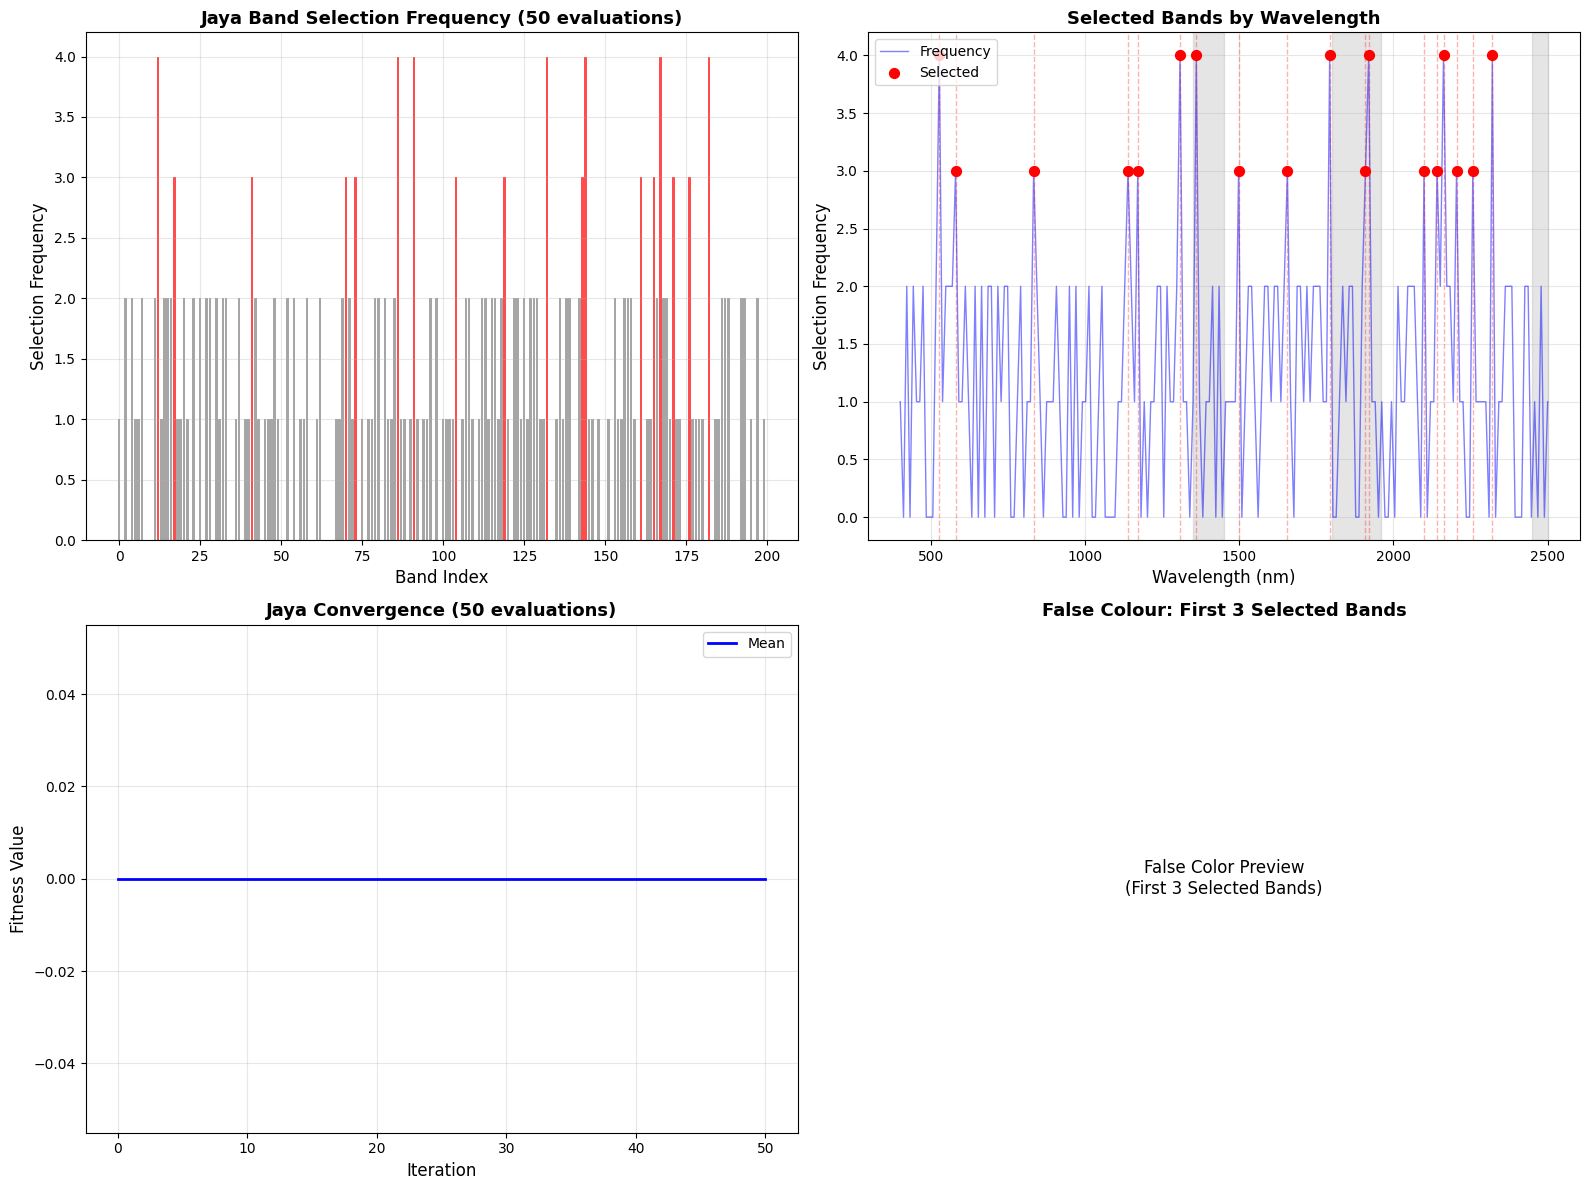

2026-02-25 09:57:39,500 - src.pipeline.preprocessing - INFO - Standardized: mean range [1.0000, 1.0000], std range [1.0000, 1.0000]


  Selected 18 bands from 200
  Selected wavelengths: [1919 1792 2162 2320 1360  526 1307 2257 1909  832 1138 1170 1655 2204
 2141  579 1497 2098] nm

[OK] Analysis Stage 2 completed in 368.86 seconds


In [8]:
# Jaya Band Selection
print("\n" + "="*70)
print("ANALYSIS STAGE 2: JAYA BAND SELECTION")
print("="*70)

stage_start = time.time()

print("\n[7.1] Running Jaya band selection...")
selected_indices, band_frequencies, cost_histories = run_jaya_with_ranking(
    cube=reflectance_cube,
    n_clusters=17,
    population_size=10,
    max_iterations=50,
    bands_per_run=5,
    n_evaluations=50,
    final_n_bands=18,
    gaussian_sigma=1.0,
    seed=42
)

print("\n[7.2] Applying band selection to cube...")
reduced_cube = apply_band_selection(reflectance_cube, selected_indices)

print("\n[7.3] Plotting band selection results...")
plot_band_selection_results(
    band_frequencies=band_frequencies,
    selected_indices=selected_indices,
    wavelengths=wavelengths,
    cost_histories=cost_histories,
    save_path=str(outputs_dir / "band_selection_results.png")
)

print(f"  Selected {len(selected_indices)} bands from {reflectance_cube.shape[0]}")
print(f"  Selected wavelengths: {wavelengths[selected_indices].astype(int)} nm")

# Normalize the reduced cube for ML
cube_normalized, norm_params = normalize_reflectance(reduced_cube, method="standardize")
cube_clean = reduced_cube  # For visualization

stage_time = time.time() - stage_start
print(f"\n[OK] Analysis Stage 2 completed in {stage_time:.2f} seconds")


## ANALYSIS STAGE 3: Spectral Unmixing

In [9]:
# Spectral unmixing
print("\n" + "="*70)
print("ANALYSIS STAGE 3: SPECTRAL UNMIXING")
print("="*70)

stage_start = time.time()

print("\n[8.1] Extracting endmembers...")
endmember_classes = [2, 10, 5, 14]  # Corn, Soybean, Grass, Woods
# Use original reflectance_cube for endmember extraction (before band selection)
endmembers, endmember_names = extract_endmembers_manual(
    reflectance_cube, labels, endmember_classes, class_names
)
print(f"  Endmembers shape: {endmembers.shape}")
print(f"  Endmember names: {endmember_names}")

print("\n[8.2] Performing FCLS unmixing...")
# Use original reflectance_cube for unmixing (before band selection)
abundances = unmix_cube(reflectance_cube, endmembers, endmember_names)


print("\n[8.3] Computing reconstruction error...")
# Use original reflectance_cube for reconstruction error
reconstruction_error = compute_reconstruction_error(reflectance_cube, abundances, endmembers)
print(f"  Mean reconstruction error: {np.nanmean(reconstruction_error.values):.4f}")
print(f"  Std reconstruction error: {np.nanstd(reconstruction_error.values):.4f}")

stage_time = time.time() - stage_start
print(f"\n[OK] Analysis Stage 3 completed in {stage_time:.2f} seconds")

2026-02-25 09:57:39,578 - src.analysis.unmixing - INFO - Extracted endmember 1/4: Corn-notill (1428 pixels)
2026-02-25 09:57:39,593 - src.analysis.unmixing - INFO - Extracted endmember 2/4: Soybean-notill (972 pixels)
2026-02-25 09:57:39,600 - src.analysis.unmixing - INFO - Extracted endmember 3/4: Grass-pasture (483 pixels)
2026-02-25 09:57:39,618 - src.analysis.unmixing - INFO - Extracted endmember 4/4: Woods (1265 pixels)
2026-02-25 09:57:39,632 - src.analysis.unmixing - INFO - Unmixing 21025 valid pixels...



ANALYSIS STAGE 3: SPECTRAL UNMIXING

[8.1] Extracting endmembers...
  Endmembers shape: (200, 4)
  Endmember names: ['Corn-notill', 'Soybean-notill', 'Grass-pasture', 'Woods']

[8.2] Performing FCLS unmixing...


Unmixing pixels: 100%|██████████| 21025/21025 [01:21<00:00, 257.70it/s]
2026-02-25 09:59:01,250 - src.analysis.unmixing - INFO - Completed unmixing: 4 endmembers
2026-02-25 09:59:01,427 - src.analysis.unmixing - INFO - Reconstruction error: mean = 0.0000, std = 0.0000



[8.3] Computing reconstruction error...
  Mean reconstruction error: 0.0000
  Std reconstruction error: 0.0000

[OK] Analysis Stage 3 completed in 81.87 seconds


## MODEL STAGE 1: SVM Classification

In [10]:
# Reload the evaluation module to get the latest fix
import importlib
import src.models.evaluation
importlib.reload(src.models.evaluation)
from src.models.evaluation import plot_classification_map, compute_metrics

print("Module reloaded successfully!")

Module reloaded successfully!


In [ ]:
# SVM Classification
print("\n" + "="*70)
print("MODEL STAGE 1: SVM CLASSIFICATION")
print("="*70)

stage_start = time.time()

print("\n[9.1] Extracting pixel matrix...")
X, y = extract_pixel_matrix(cube_normalized, labels, exclude_unlabeled=True)
print(f"  X shape: {X.shape}, y shape: {y.shape}")
print(f"  Number of classes: {len(np.unique(y))}")

print("\n[9.2] Creating spatial blocks...")
block_ids = create_spatial_blocks(labels, n_blocks=5)
print(f"  Block IDs shape: {block_ids.shape}")
print(f"  Number of unique blocks: {len(np.unique(block_ids))}")

print("\n[9.3] Running spatial cross-validation...")
svm_results = run_spatial_cv(X, y, block_ids, n_blocks=5)

print(f"\n  SVM Results:")
print(f"    Overall Accuracy: {svm_results['overall_accuracy']['mean']:.4f} ± {svm_results['overall_accuracy']['std']:.4f}")
print(f"    Kappa: {svm_results['kappa']['mean']:.4f} ± {svm_results['kappa']['std']:.4f}")

stage_time = time.time() - stage_start
print(f"\n[OK] Model Stage 1 completed in {stage_time:.2f} seconds")

2026-02-25 09:59:01,515 - src.pipeline.preprocessing - INFO - Extracted 10249 labeled pixels (excluded 10776 unlabeled)
2026-02-25 09:59:01,568 - src.models.svm_classifier - INFO - Created 5×5 = 25 spatial blocks
2026-02-25 09:59:01,592 - src.models.svm_classifier - INFO - 
=== Fold 1/25 (test block 0) ===
2026-02-25 09:59:01,602 - src.models.svm_classifier - INFO - Split: train=9408, test=841 (block 0)
2026-02-25 09:59:01,605 - src.models.svm_classifier - INFO - Training SVM with fixed hyperparameters...



MODEL STAGE 1: SVM CLASSIFICATION

[9.1] Extracting pixel matrix...
  X shape: (10249, 18), y shape: (10249,)
  Number of classes: 16

[9.2] Creating spatial blocks...
  Block IDs shape: (145, 145)
  Number of unique blocks: 25

[9.3] Running spatial cross-validation...


2026-02-25 10:00:15,158 - src.models.evaluation - INFO - Overall Accuracy: 0.0892
2026-02-25 10:00:15,159 - src.models.evaluation - INFO - Kappa: 0.0000
2026-02-25 10:00:15,160 - src.models.evaluation - INFO - Macro F1: 0.0136
2026-02-25 10:00:15,162 - src.models.svm_classifier - INFO - Fold 1: OA = 0.0892, Kappa = 0.0000
2026-02-25 10:00:15,167 - src.models.svm_classifier - INFO - 
=== Fold 2/25 (test block 1) ===
2026-02-25 10:00:15,175 - src.models.svm_classifier - INFO - Split: train=9408, test=841 (block 1)
2026-02-25 10:00:15,177 - src.models.svm_classifier - INFO - Training SVM with fixed hyperparameters...
2026-02-25 10:02:01,134 - src.models.evaluation - INFO - Overall Accuracy: 0.1498
2026-02-25 10:02:01,140 - src.models.evaluation - INFO - Kappa: 0.0000
2026-02-25 10:02:01,143 - src.models.evaluation - INFO - Macro F1: 0.0217
2026-02-25 10:02:01,146 - src.models.svm_classifier - INFO - Fold 2: OA = 0.1498, Kappa = 0.0000
2026-02-25 10:02:01,149 - src.models.svm_classifier - 

In [ ]:
# Train final SVM model for visualization
print("\n[9.4] Training final SVM model...")
spatial_positions = np.zeros((len(y), 2), dtype=int)
n_y, n_x = labels.shape
for i in range(len(y)):
    y_pos = i // n_x
    x_pos = i % n_x
    spatial_positions[i] = [y_pos, x_pos]

# Use 80% for training, 20% for test
split_idx = int(0.8 * len(X))
X_train_svm = X[:split_idx]
X_test_svm = X[split_idx:]
y_train_svm = y[:split_idx]
y_test_svm = y[split_idx:]

print(f"  Training samples: {len(y_train_svm)}, Test samples: {len(y_test_svm)}")

svm_pipeline = train_svm_classifier(X_train_svm, y_train_svm, optimize=False)
y_pred_svm = svm_pipeline.predict(X_test_svm)
svm_metrics = compute_metrics(y_test_svm, y_pred_svm, class_names)

print(f"\n  Final SVM Metrics:")
print(f"    Overall Accuracy: {svm_metrics['overall_accuracy']:.4f}")
print(f"    Kappa: {svm_metrics['kappa']:.4f}")
print(f"    Macro F1: {svm_metrics['macro_f1']:.4f}")


## VISUALIZATIONS

In [ ]:
# Reload visualization module to get the latest fix
import importlib
import src.visualization.plots
importlib.reload(src.visualization.plots)
from src.visualization.plots import plot_false_color_composite, plot_spectral_signatures

print("Visualization module reloaded successfully!")


In [ ]:
# Generate additional visualizations
print("\n" + "="*70)
print("GENERATING VISUALIZATIONS")
print("="*70)

print("\n[11.1] False color composite...")
plot_false_color_composite(
    cube_clean, save_path=str(outputs_dir / "false_color_composite.png")
)

print("\n[11.2] Spectral signatures...")


print("\nAll visualizations saved to outputs/ directory")

## Summary

Pipeline execution complete! All outputs have been saved to the `outputs/` directory.

In [ ]:
# Final summary
print("\n" + "="*70)
print("PIPELINE COMPLETE")
print("="*70)
print(f"\nOutputs saved to: {outputs_dir.absolute()}")
print("\nGenerated files:")
for file in sorted(outputs_dir.glob("*.png")):
    print(f"  - {file.name}")
print("\n" + "="*70)